# Clustering audio à partir des fichiers chroma

On utilise ici la technique proposée dans l'article suivant : "USING CHROMA HISTOGRAM TO MEASURE THE PERCEPTUAL SIMILARITY OF
MUSIC", disponible à l'adresse https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=4607685

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.express as px
from plotly.offline import plot
import plotly.io as pio
from sklearn.manifold import MDS
import librosa
from scipy.cluster.hierarchy import linkage, dendrogram

In [4]:
def verbose(message, verbose_level, verbose_threshold=0):
    if verbose_level > verbose_threshold:
        print(message)

In [3]:
filename = "cross-composer\chroma-nnls_01_bach.csv"
li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']

<>:1: SyntaxWarning:

invalid escape sequence '\c'

<>:1: SyntaxWarning:

invalid escape sequence '\c'

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\2910331894.py:1: SyntaxWarning:

invalid escape sequence '\c'



In [5]:
def chromagram(data):
    li_notes = ['A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    plt.figure(figsize=(10, 4))
    plt.imshow(data.T, aspect='auto', origin='lower', cmap='coolwarm')
    plt.colorbar(label='Energy')
    plt.title('Chromagram')
    plt.xlabel('Time (Frames)')
    plt.ylabel('Chroma Features')
    #plt.xticks(ticks=np.arange(0, 100, 10), labels=np.arange(0, 100, 10))  # Ajustez les ticks si nécessaire
    plt.yticks(ticks=np.arange(12), labels=li_notes)  # Noms des chroma
    plt.tight_layout()
    plt.show()

## Conversion en chroma histograms

In [5]:
filename = "cross-composer\chroma-nnls_01_bach.csv"
li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
N=3
loudness_resolution = 50
overlap = 0.5

<>:1: SyntaxWarning:

invalid escape sequence '\c'

<>:1: SyntaxWarning:

invalid escape sequence '\c'

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\3313903304.py:1: SyntaxWarning:

invalid escape sequence '\c'



In [14]:
def get_dataframes(filename, verb):
    """Renvoie un dictionaire sous la forme titre : dataframe des chroma features"""
    li_notes = ['time','A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    df = pd.read_csv(filename)
    title = None
    dataf = []
    dataframes = {}
    for i, row in df.iterrows():
        if pd.notna(row[0]):
            if title is not None:
                dataframes[title] = pd.DataFrame(dataf, columns=li_notes)
                dataframes[title].set_index('time', inplace=True)
            title = row[0]
            dataf = []
        else:
            dataf.append(row[1:].tolist())

    if title is not None:
        dataframes[title] = pd.DataFrame(dataf, columns=li_notes)
        dataframes[title].set_index('time', inplace=True)
    verbose(f"Dataframes obtenus : {dataframes}", verb, 0)
    return dataframes

In [15]:
def quantize(dataframe, loudness_resolution, verb):
    """Quantifie les valeurs de chroma features entre 0 et loudness_resolution"""
    dataframe = dataframe.to_numpy()
    dataframe/= np.max(dataframe)
    dataframe = np.ceil(dataframe * loudness_resolution)
    verbose(f"Tableau quantifié : {dataframe}", verb, 0)
    return dataframe

In [16]:
def get_frames(dataframe,N,overlap, verb):
    """Découpe le dataframe en 2**N frames avec une proportion overlap de recoupement"""
    step = int((1-overlap)*len(dataframe)/2**N)
    frames = []
    for i in range(2**N):
        frames.append(dataframe[i*step:(i+1)*step,:])
    verbose(f"Nouvelles frames : {frames}", verb, 0)
    return frames

In [17]:
def histogram(frame,loudness_resolution,verb, affiche = False):
    """Renvoie l'histogramme de la frame"""
    step = frame.shape[0]
    histogram = np.zeros((loudness_resolution+1, 12))
    for i in range(step):
        for j in range(12):
            loudness_level = int(frame[i, j])
            for k in range(loudness_level+1):
                histogram[k, j] += 1
    histogram /= np.max(histogram)
    if affiche:
        plt.figure(figsize=(5,10))
        sns.heatmap(histogram, cmap='coolwarm', cbar=True, xticklabels=li_notes[1:], yticklabels=np.arange(loudness_resolution+1))
        plt.title('Histogramme de la frame')
        plt.xlabel('Chroma Features')
        plt.ylabel('Loudness Level')
        plt.show()
    return histogram

In [18]:
def dico_hist(filename,loudness_resolution=50,N=3,overlap=0.5,verb=0):
    dataframes = get_dataframes(filename, verb)
    res = {}
    for titre, dataframe in dataframes.items():
        data = quantize(dataframe, loudness_resolution, verb)
        frames = get_frames(data, N, overlap, verb)
        histograms = []
        for frame in frames:
            histograms.append(histogram(frame, loudness_resolution, verb))
        res[titre] = histograms
    verbose(f"Dictionnaire d'histogrammes : {res}", verb, 0)
    return res

In [48]:
dico = dico_hist(filename)

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\3027109082.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\3027109082.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [55]:
def plot_histogram(hist):
    li_notes = ['A','A#','B','C','C#','D','D#','E','F','F#','G','G#']
    plt.figure(figsize=(7,8))
    sns.heatmap(hist, cmap = 'coolwarm', cbar=True, xticklabels=np.array(li_notes), yticklabels=np.arange(loudness_resolution+1))
    plt.title('Histogramme de la frame')
    plt.xlabel('Chroma Features')
    plt.ylabel('Loudness Level')
    plt.show()

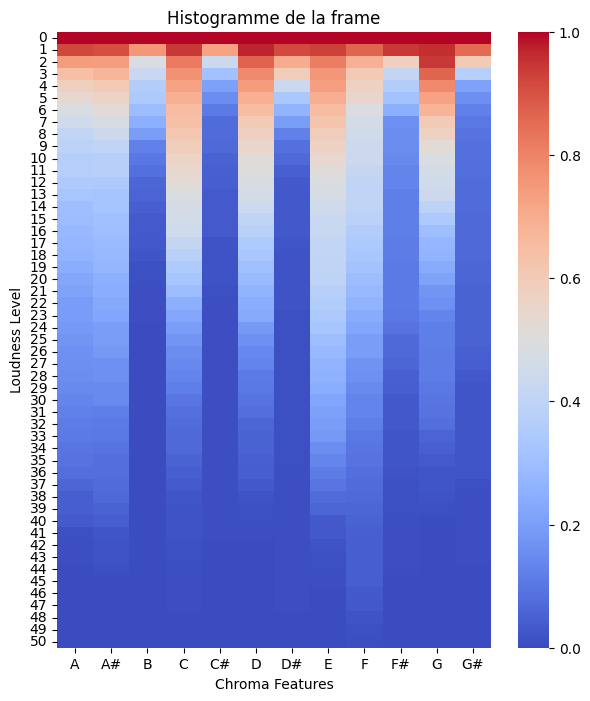

In [56]:
hist = dico['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3']
plot_histogram(hist[0])

In [58]:
with open ('hist_bach.pkl', 'wb') as f:
    pickle.dump(dico, f)

## Pre-processing des données

In [59]:
dico = pickle.load(open('hist_bach.pkl', 'rb'))

In [61]:
len(dico['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3'])

8

In [63]:
def transpose(hist,shift):
    """Transposition de l'histogramme de shift"""
    hist2 = np.roll(hist, shift, axis=1)
    return hist2

In [69]:
def distance_eucl(hist1, hist2):
    """Calcul la distance entre deux histogrammes.
    A modifier si on veut une autre distance !"""
    return np.sqrt(np.sum((hist1 - hist2)**2))

In [70]:
def distance(hist0,hist1):
    return min([distance_eucl(hist0, transpose(hist1, i)) for i in range(12)])

def distance_morceaux(frames0,frames1):
    return sum([distance(frames0[i],frames1[i]) for i in range(len(frames0))])

In [76]:
hist = dico['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3']
hist2 = dico['01_bach/CrossComp-0071_01_bach_trio_gdur_bwv_586.mp3']
distance(hist,hist2)

10.97907223218914

## Clustering par dendrogramme

In [ ]:
def distance_matrix_df(dico):
    clefs = list(dico.keys())
    items = list(dico.values())
    data = {}
    data['Nom'] =  clefs
    for i in range(len(clefs)):
        distances = [distance_morceaux(items[i], items[j]) for j in range(len(clefs))]
        data['Distances ' + str(clefs[i])] = distances
    df = pd.DataFrame(data)
    return df

In [97]:
def distance_matrix(dico):
    clefs = list(dico.keys())
    items = list(dico.values())
    mat = np.zeros((len(clefs), len(clefs)))
    for i in range(len(clefs)):
        for j in range(len(clefs)):
            mat[i][j] = distance_morceaux(items[i], items[j])
    return clefs,mat

In [98]:
distance_matrix(dico)

(['01_bach/CrossComp-0056_01_bach_11_bwv_880_in_fmaj.mp3',
  '01_bach/CrossComp-0057_01_bach_12_bwv_881_in_fmin.mp3',
  '01_bach/CrossComp-0058_01_bach_13_bwv_882_in_fmaj.mp3',
  '01_bach/CrossComp-0059_01_bach_14_bwv_883_in_fmin.mp3',
  '01_bach/CrossComp-0060_01_bach_15_bwv_884_in_gmaj.mp3',
  '01_bach/CrossComp-0061_01_bach_16_bwv_885_in_gmin.mp3',
  '01_bach/CrossComp-0062_01_bach_17_bwv_886_in_abmaj.mp3',
  '01_bach/CrossComp-0063_01_bach_18_bwv_887_in_abmin.mp3',
  '01_bach/CrossComp-0064_01_bach_19_bwv_888_in_amaj.mp3',
  '01_bach/CrossComp-0046_01_bach_1_bwv_870_in_cmaj.mp3',
  '01_bach/CrossComp-0065_01_bach_20_bwv_889_in_amin.mp3',
  '01_bach/CrossComp-0066_01_bach_21_bwv_890_in_bbmaj.mp3',
  '01_bach/CrossComp-0067_01_bach_22_bwv_891_in_bbmin.mp3',
  '01_bach/CrossComp-0068_01_bach_23_bwv_892_in_bmaj.mp3',
  '01_bach/CrossComp-0069_01_bach_24_bwv_893_in_bmin.mp3',
  '01_bach/CrossComp-0047_01_bach_2_bwv_871_in_cmin.mp3',
  '01_bach/CrossComp-0048_01_bach_3_bwv_872_in_cmaj.mp

In [112]:
def plot_dendrogram(dico, figs = (10, 7)):
    titres,mat = distance_matrix(dico)
    Z = linkage(mat, 'ward')
    plt.figure(figsize=figs)
    dendrogram(Z, labels=titres, leaf_rotation=90)
    plt.title('Dendrogramme des morceaux')
    plt.xlabel('Morceaux')
    plt.ylabel('Distance')
    plt.show()

### Application aux morceaux de Bach

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\507386658.py:3: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



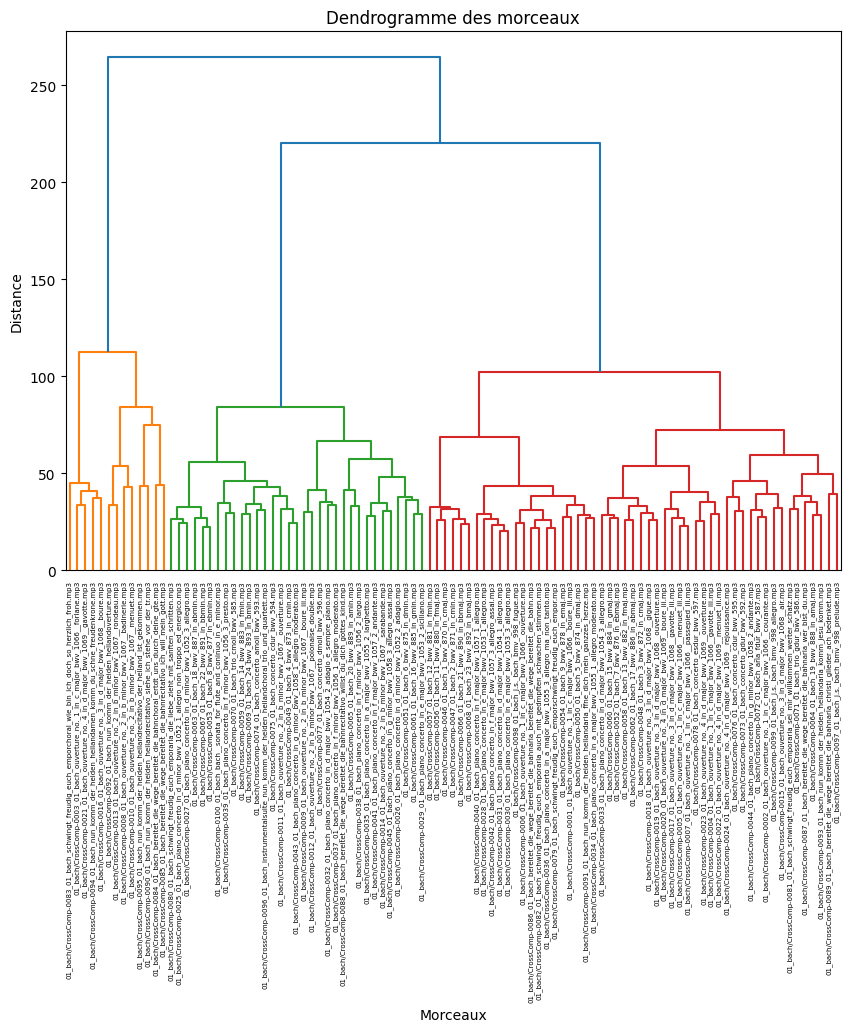

In [101]:
plot_dendrogram(dico)

### Et si on rajoutait Beethoven dans l'affaire ?

In [6]:
filename = "cross-composer\chroma-nnls_02_beethoven.csv"

In [7]:
dico_beethoven = dico_hist(filename)
with open ('hist_beethoven.pkl', 'wb') as f:
    pickle.dump(dico_beethoven, f)

NameError: name 'dico_hist' is not defined

In [8]:
dico_bach = pickle.load(open('hist_bach.pkl', 'rb'))
dico_beethoven = pickle.load(open('hist_beethoven.pkl', 'rb'))
dico = dico_bach | dico_beethoven

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_13028\4093079893.py:3: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



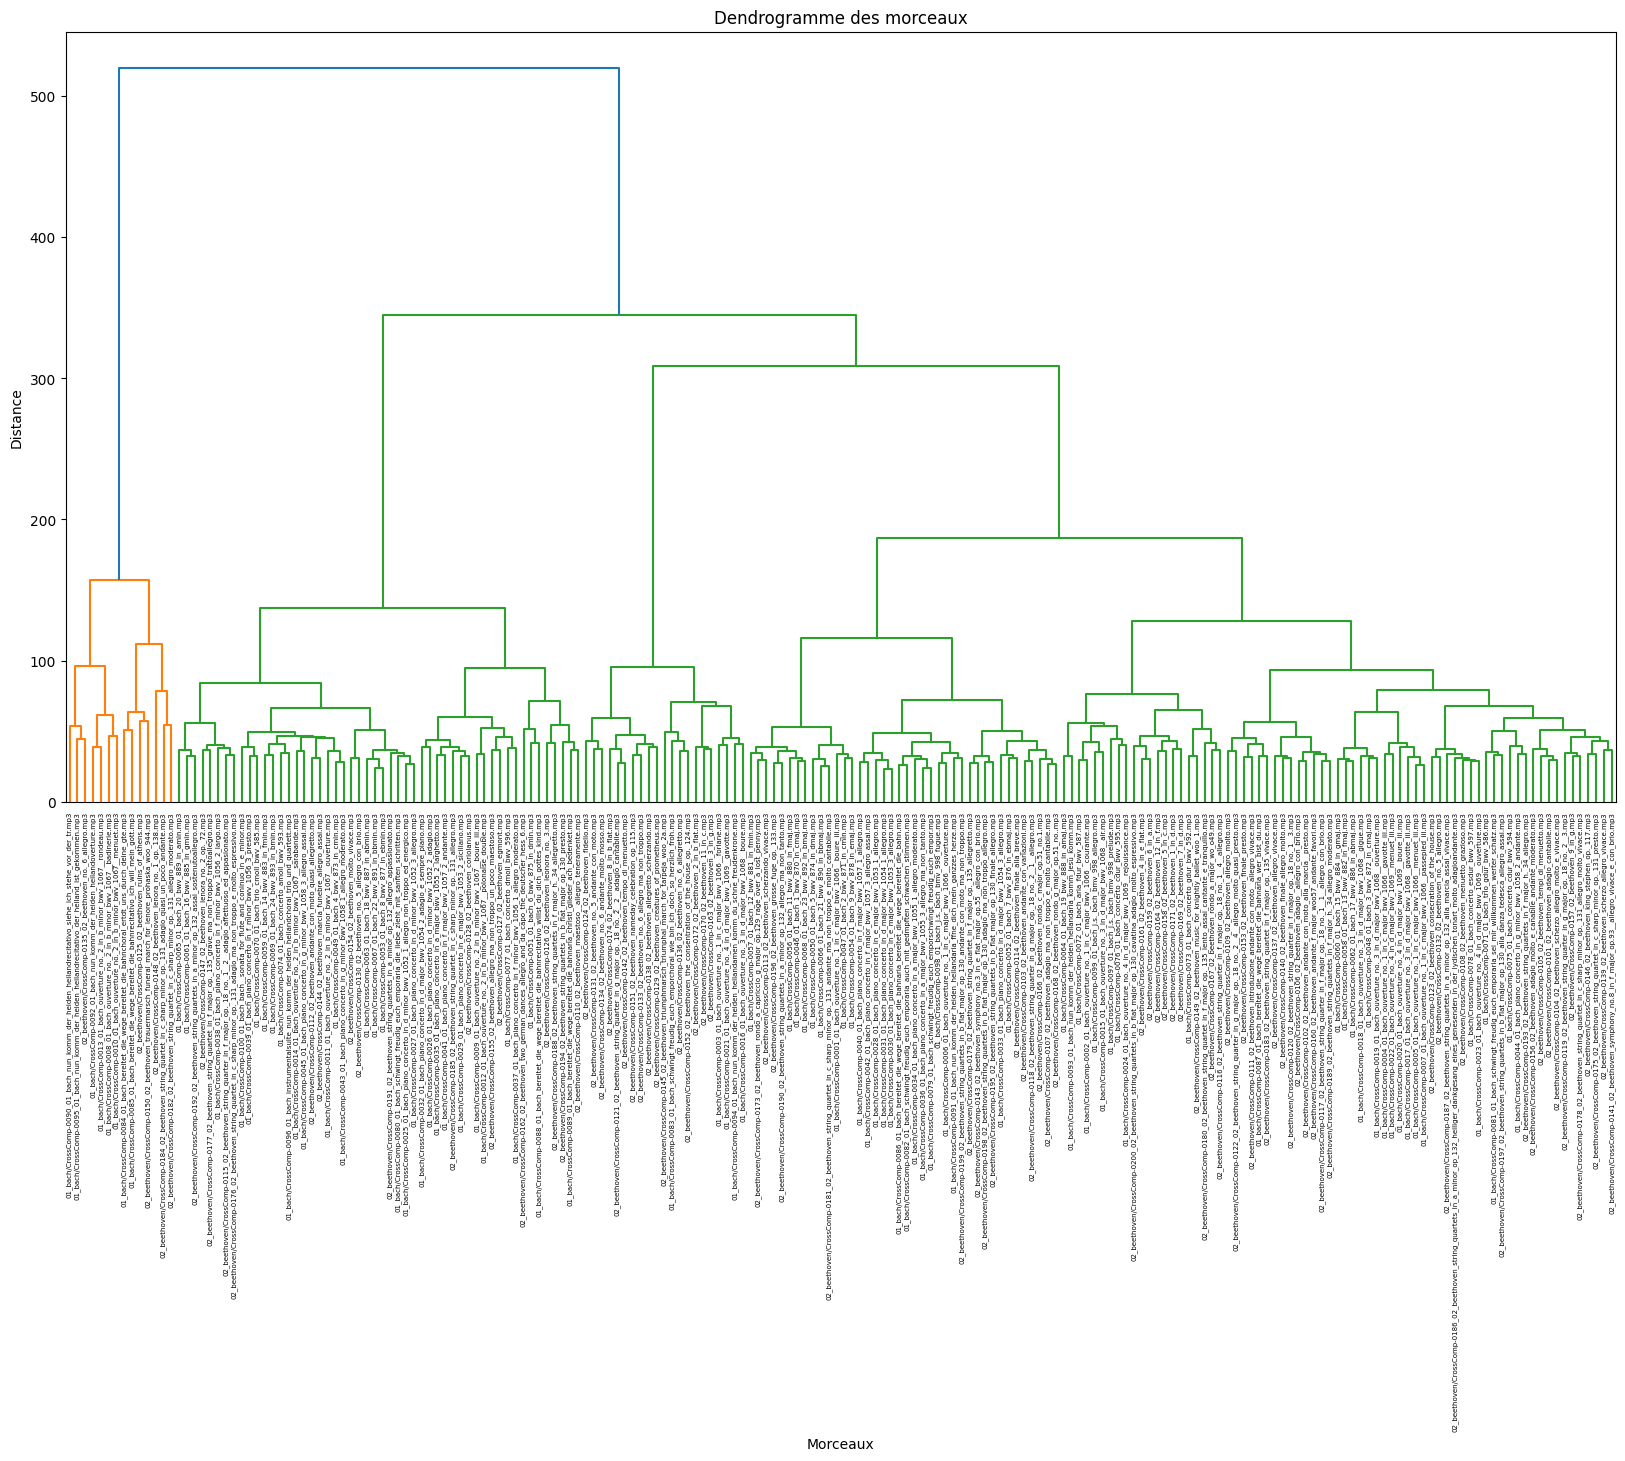

In [114]:
plot_dendrogram(dico, figs = (20, 10))

## Utilisation du DTW

In [11]:
def distance_matrix_dtw(dico):
    clefs = list(dico.keys())
    items = list(dico.values())
    mat = np.zeros((len(clefs), len(clefs)))
    for i in range(len(clefs)):
        for j in range(len(clefs)):
            D, wp = librosa.sequence.dtw(items[i],items[j])
            mat[i][j] = D[-1,-1]
    return clefs,mat

In [12]:
def plot_dendrogram_dtw(dico, figs = (10, 7)):
    titres,mat = distance_matrix_dtw(dico)
    Z = linkage(mat, 'ward')
    plt.figure(figsize=figs)
    dendrogram(Z, labels=titres, leaf_rotation=90)
    plt.title('Dendrogramme des morceaux')
    plt.xlabel('Morceaux')
    plt.ylabel('Distance')
    plt.show()

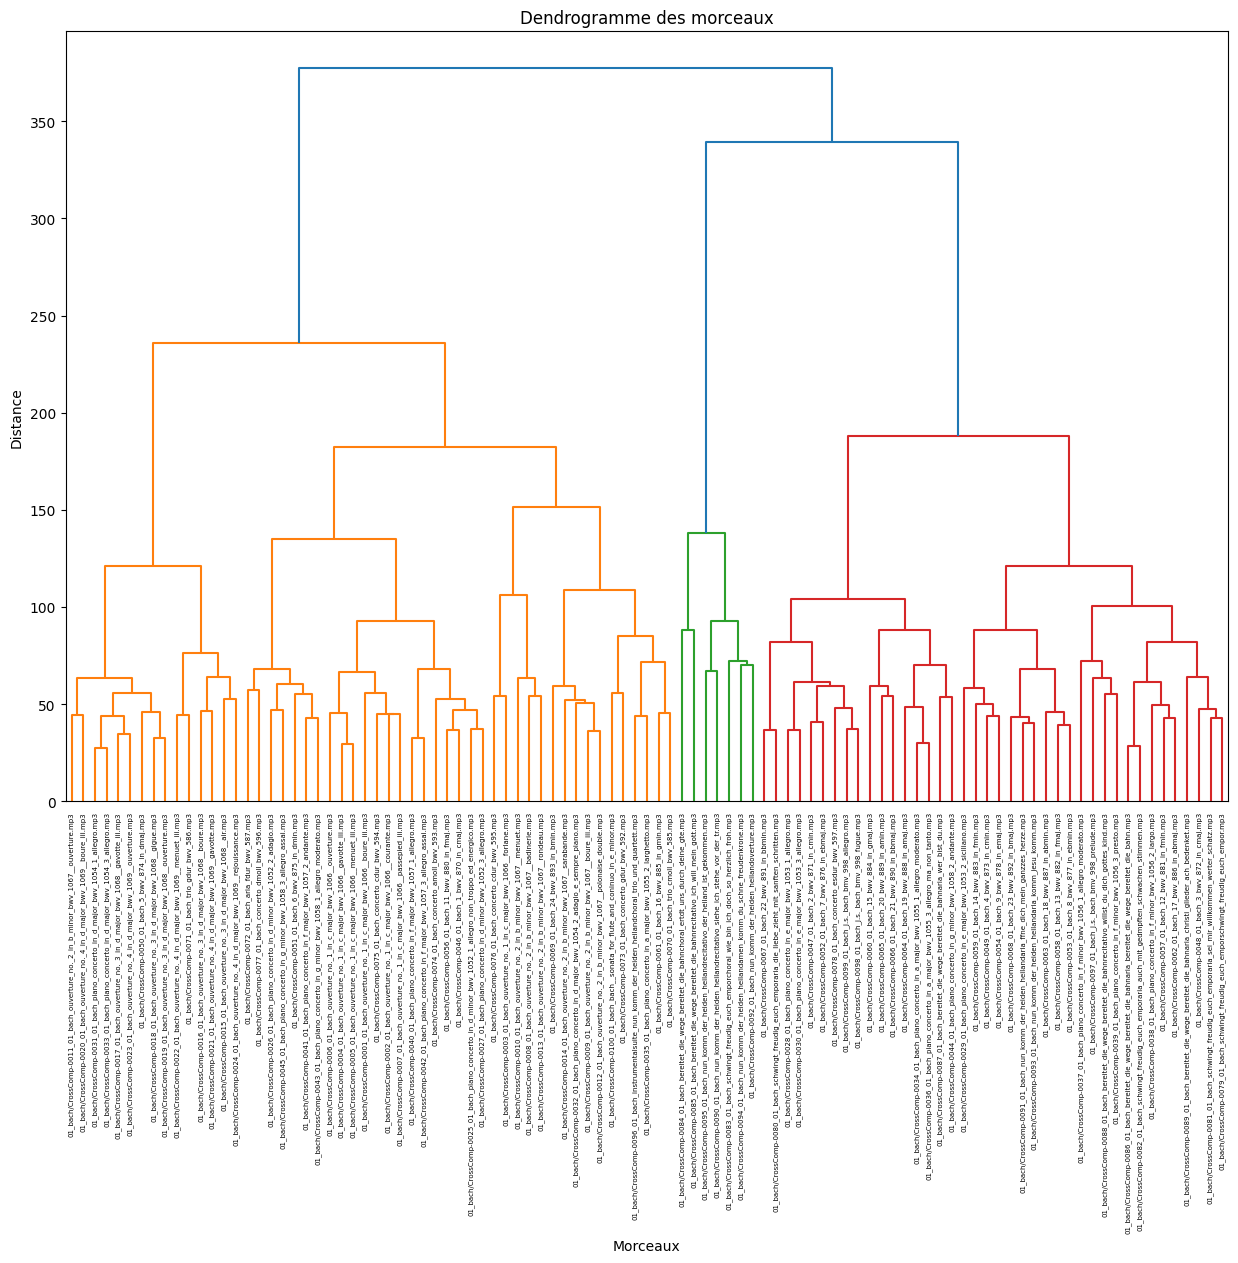

In [17]:
plot_dendrogram_dtw(dico_bach,figs = (15, 10))